In [61]:
!pip install keras-tuner -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import os

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score, roc_curve, auc, precision_recall_curve

# Deep Learning Libraries
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical

sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12})


In [62]:
#LOAD DATA
df = pd.read_csv("urban_building_stock_datasets_17042024.csv")


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048562 entries, 0 to 1048561
Data columns (total 31 columns):
 #   Column                                 Non-Null Count    Dtype  
---  ------                                 --------------    -----  
 0   Simple_Building_Energy_Rating          1048562 non-null  object 
 1   Weather_File                           1048562 non-null  object 
 2   Building_Type                          1048562 non-null  object 
 3   Renewable_Energy_Usage                 1048562 non-null  object 
 4   Floor_Insulation_U-Value               1048562 non-null  float64
 5   Door_Insulation_U-Value                1048562 non-null  float64
 6   Roof_Insulation_U-Value                1048562 non-null  float64
 7   Window_Insulation_U-Value              1048562 non-null  float64
 8   Wall_Insulation_U-Value                1048562 non-null  float64
 9   Building_Energy_Rating                 1048562 non-null  object 
 10  HVAC_Efficiency                        104

In [64]:
df.describe()

,Floor_Insulation_U-Value,Door_Insulation_U-Value,Roof_Insulation_U-Value,Window_Insulation_U-Value,Wall_Insulation_U-Value,HVAC_Efficiency,Domestic_Hot_Water_Usage,Building_Orientation,Lighting_Density,Occupancy_Level,...,Total_Heating_Energy,Interior_Lighting_Energy,Interior_Equipment_Energy,Heating_Energy,Photovoltaic_Power,Total_Electricity_Energy,Electricity_Primary_Conversion_Factor,Heating_Primary_Conversion_Factor,Energy_Use_Intensity,Water_Systems_Energy
count,1.048562e+06,1.048562e+06,1.048562e+06,1.048562e+06,1.048562e+06,1.048562e+06,1.048562e+06,1.048562e+06,1.048562e+06,1.048562e+06,...,1.048562e+06,1.048562e+06,1.048562e+06,1.048562e+06,1.048562e+06,1.048562e+06,1.048562e+06,1.048562e+06,1.048562e+06,1.048562e+06
mean,3.759510e-01,2.289789e+00,8.799751e-01,2.447411e+00,1.033975e+00,2.801190e+00,1.658863e+00,1.253720e+02,4.587080e+00,3.517278e+00,...,8.744268e+03,1.149838e+03,3.081401e+03,7.540453e+03,5.154063e+02,3.741603e+03,1.830000e+00,1.665252e+00,1.800157e+02,1.203815e+03
std,2.811865e-01,1.413139e+00,7.303162e-01,1.585775e+00,7.609317e-01,1.340522e+00,1.155431e+00,1.117817e+02,2.748825e+00,1.707378e+00,...,1.141903e+04,7.255468e+02,2.215825e+03,1.035758e+04,4.711789e+02,2.555281e+03,4.884984e-15,3.051627e-01,1.255218e+02,1.724227e+03
min,1.500000e-01,8.100000e-01,7.000000e-02,7.300000e-01,1.000000e-01,3.000000e-01,5.000000e-01,0.000000e+00,1.000000e+00,1.000000e+00,...,7.890952e+01,2.079600e+02,2.439700e+02,0.000000e+00,0.000000e+00,-6.902600e+02,1.830000e+00,1.100000e+00,-7.610005e+00,7.045778e+01
25%,1.800000e-01,1.010000e+00,1.000000e-01,1.060000e+00,3.500000e-01,2.000000e+00,5.000000e-01,0.000000e+00,3.000000e+00,2.000000e+00,...,1.836417e+03,6.238900e+02,1.463840e+03,1.391672e+03,0.000000e+00,1.726226e+03,1.830000e+00,1.830000e+00,8.590326e+01,1.951048e+02
50%,3.000000e-01,2.190000e+00,7.300000e-01,2.030000e+00,9.000000e-01,3.200000e+00,1.500000e+00,9.000000e+01,5.000000e+00,4.000000e+00,...,4.229212e+03,1.039820e+03,2.683710e+03,3.422495e+03,4.836580e+02,3.364080e+03,1.830000e+00,1.830000e+00,1.579801e+02,6.342825e+02
75%,4.400000e-01,2.940000e+00,1.510000e+00,3.210000e+00,1.840000e+00,4.000000e+00,2.500000e+00,2.250000e+02,7.000000e+00,5.000000e+00,...,1.093400e+04,1.599880e+03,4.794450e+03,9.179735e+03,9.634040e+02,5.518535e+03,1.830000e+00,1.830000e+00,2.342675e+02,1.365738e+03
max,1.600000e+00,5.700000e+00,2.280000e+00,5.750000e+00,2.400000e+00,4.500000e+00,3.500000e+00,3.150000e+02,9.000000e+00,6.000000e+00,...,9.016493e+04,2.879780e+03,8.174230e+03,7.699922e+04,1.233250e+03,1.105402e+04,1.830000e+00,1.830000e+00,7.704019e+02,1.912033e+04


In [65]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1048562, 31)


In [66]:
df.head()

,Simple_Building_Energy_Rating,Weather_File,Building_Type,Renewable_Energy_Usage,Floor_Insulation_U-Value,Door_Insulation_U-Value,Roof_Insulation_U-Value,Window_Insulation_U-Value,Wall_Insulation_U-Value,Building_Energy_Rating,...,Total_Heating_Energy,Interior_Lighting_Energy,Interior_Equipment_Energy,Heating_Energy,Photovoltaic_Power,Total_Electricity_Energy,Electricity_Primary_Conversion_Factor,Heating_Primary_Conversion_Factor,Energy_Use_Intensity,Water_Systems_Energy
0,A,Historical,Detached,Yes,0.16,0.81,0.10,0.91,0.21,A1,...,914.354762,319.98,389.25,719.250000,974.475,-216.530,1.83,1.83,9.762398,195.104762
1,B,Historical,Bungalow,Yes,0.21,1.01,2.13,5.45,1.03,B1,...,2926.219444,207.96,1463.84,2309.708333,856.865,857.782,1.83,1.83,80.604384,616.511111
2,A,Historical,Detached,Yes,0.16,1.01,0.07,0.79,0.30,A2,...,989.072093,319.98,2335.50,798.504651,974.475,1729.720,1.83,1.83,38.035238,190.567442
3,E,Historical,Bungalow,No,0.50,3.00,0.60,0.79,1.50,E1,...,8732.068182,1039.82,5123.44,8011.468182,0.000,6163.258,1.83,1.83,317.290733,720.600000
4,A,Historical,Semi Detached,Yes,0.18,1.01,0.10,0.79,0.10,A2,...,771.563415,773.91,1878.02,607.024390,963.467,1736.636,1.83,1.83,42.622388,164.539024


In [67]:
# Data Types
print("\nData Types:")
print(df.dtypes)


Data Types:
Simple_Building_Energy_Rating             object
Weather_File                              object
Building_Type                             object
Renewable_Energy_Usage                    object
Floor_Insulation_U-Value                 float64
Door_Insulation_U-Value                  float64
Roof_Insulation_U-Value                  float64
Window_Insulation_U-Value                float64
Wall_Insulation_U-Value                  float64
Building_Energy_Rating                    object
HVAC_Efficiency                          float64
Domestic_Hot_Water_Usage                 float64
Building_Orientation                       int64
Lighting_Density                           int64
Occupancy_Level                            int64
Equipment_Density                          int64
Heating_Setpoint_Temperature               int64
Heating_Setback_Temperature                int64
Air_Change_Rate                          float64
Window_to_Wall_Ratio                       int64
Total_B

In [68]:
# Missing Values
print("\nMissing Values:")
print(df.isna().sum())


Missing Values:
Simple_Building_Energy_Rating            0
Weather_File                             0
Building_Type                            0
Renewable_Energy_Usage                   0
Floor_Insulation_U-Value                 0
Door_Insulation_U-Value                  0
Roof_Insulation_U-Value                  0
Window_Insulation_U-Value                0
Wall_Insulation_U-Value                  0
Building_Energy_Rating                   0
HVAC_Efficiency                          0
Domestic_Hot_Water_Usage                 0
Building_Orientation                     0
Lighting_Density                         0
Occupancy_Level                          0
Equipment_Density                        0
Heating_Setpoint_Temperature             0
Heating_Setback_Temperature              0
Air_Change_Rate                          0
Window_to_Wall_Ratio                     0
Total_Building_Area                      0
Total_Heating_Energy                     0
Interior_Lighting_Energy             

In [69]:
# Summary Statistics
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
       Floor_Insulation_U-Value  Door_Insulation_U-Value  \
count              1.048562e+06             1.048562e+06   
mean               3.759510e-01             2.289789e+00   
std                2.811865e-01             1.413139e+00   
min                1.500000e-01             8.100000e-01   
25%                1.800000e-01             1.010000e+00   
50%                3.000000e-01             2.190000e+00   
75%                4.400000e-01             2.940000e+00   
max                1.600000e+00             5.700000e+00   

       Roof_Insulation_U-Value  Window_Insulation_U-Value  \
count             1.048562e+06               1.048562e+06   
mean              8.799751e-01               2.447411e+00   
std               7.303162e-01               1.585775e+00   
min               7.000000e-02               7.300000e-01   
25%               1.000000e-01               1.060000e+00   
50%               7.300000e-01               2.030000e+00   
75%        

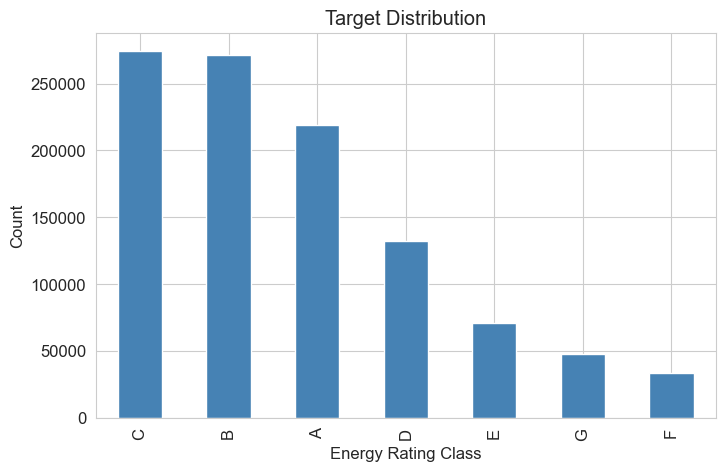

In [70]:
# Target Distribution
plt.figure(figsize=(8, 5))
df["Simple_Building_Energy_Rating"].value_counts().plot(kind='bar', color='steelblue')
plt.title("Target Distribution")
plt.xlabel("Energy Rating Class")
plt.ylabel("Count")
plt.show()

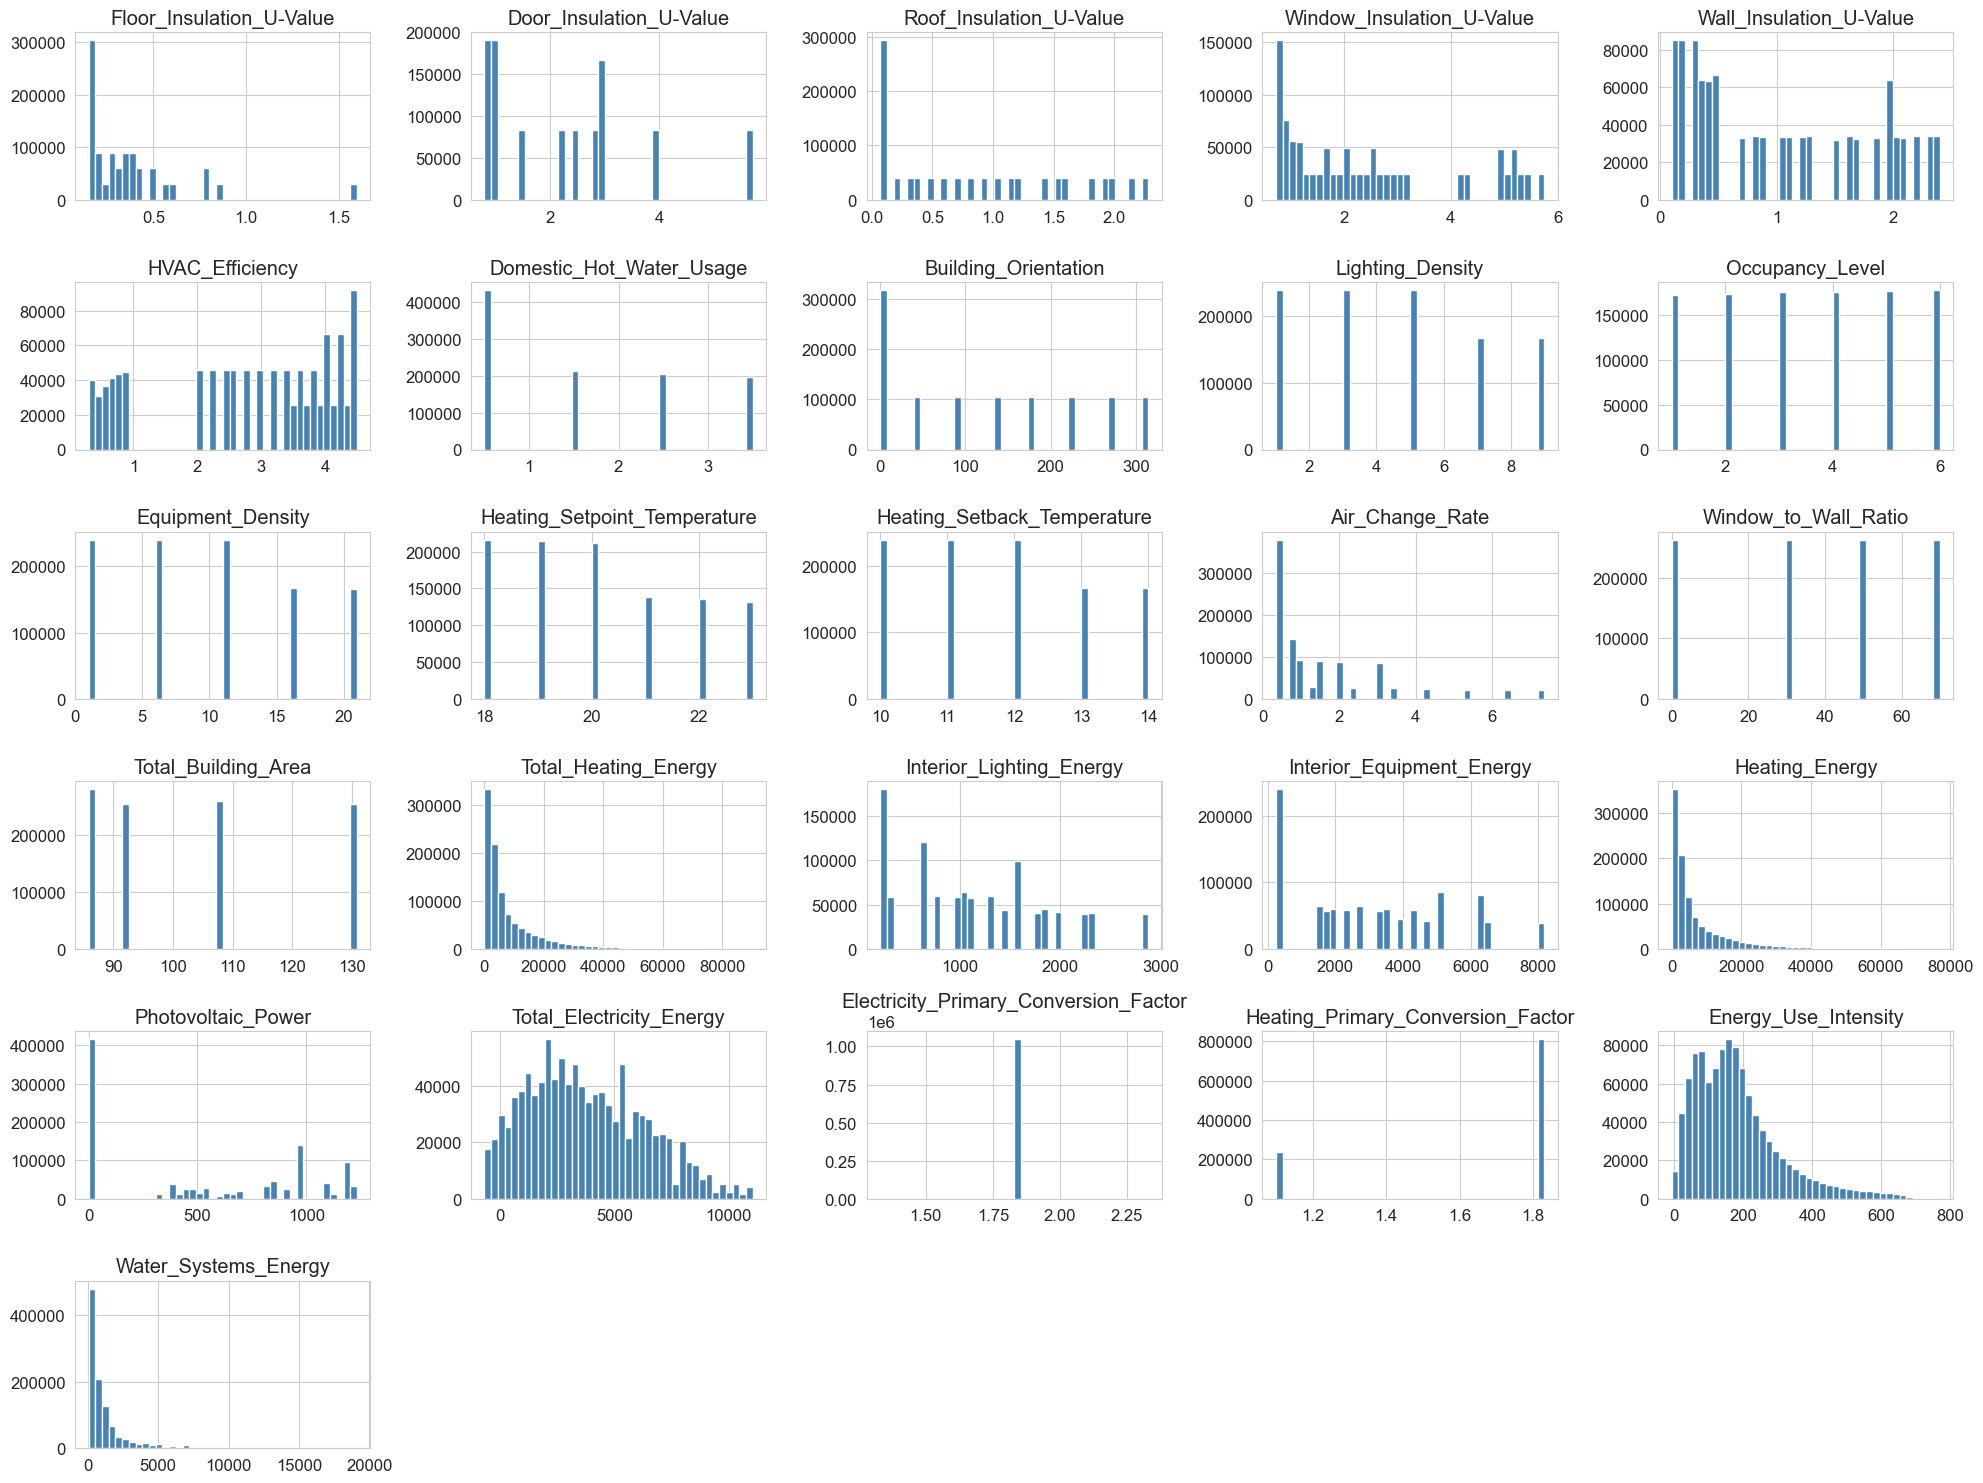

In [71]:
# Numeric Column Distribution
numeric_cols = df.select_dtypes(include=[np.number]).columns

df[numeric_cols].hist(bins=40, figsize=(20, 15), color='steelblue')
plt.tight_layout()
plt.show()

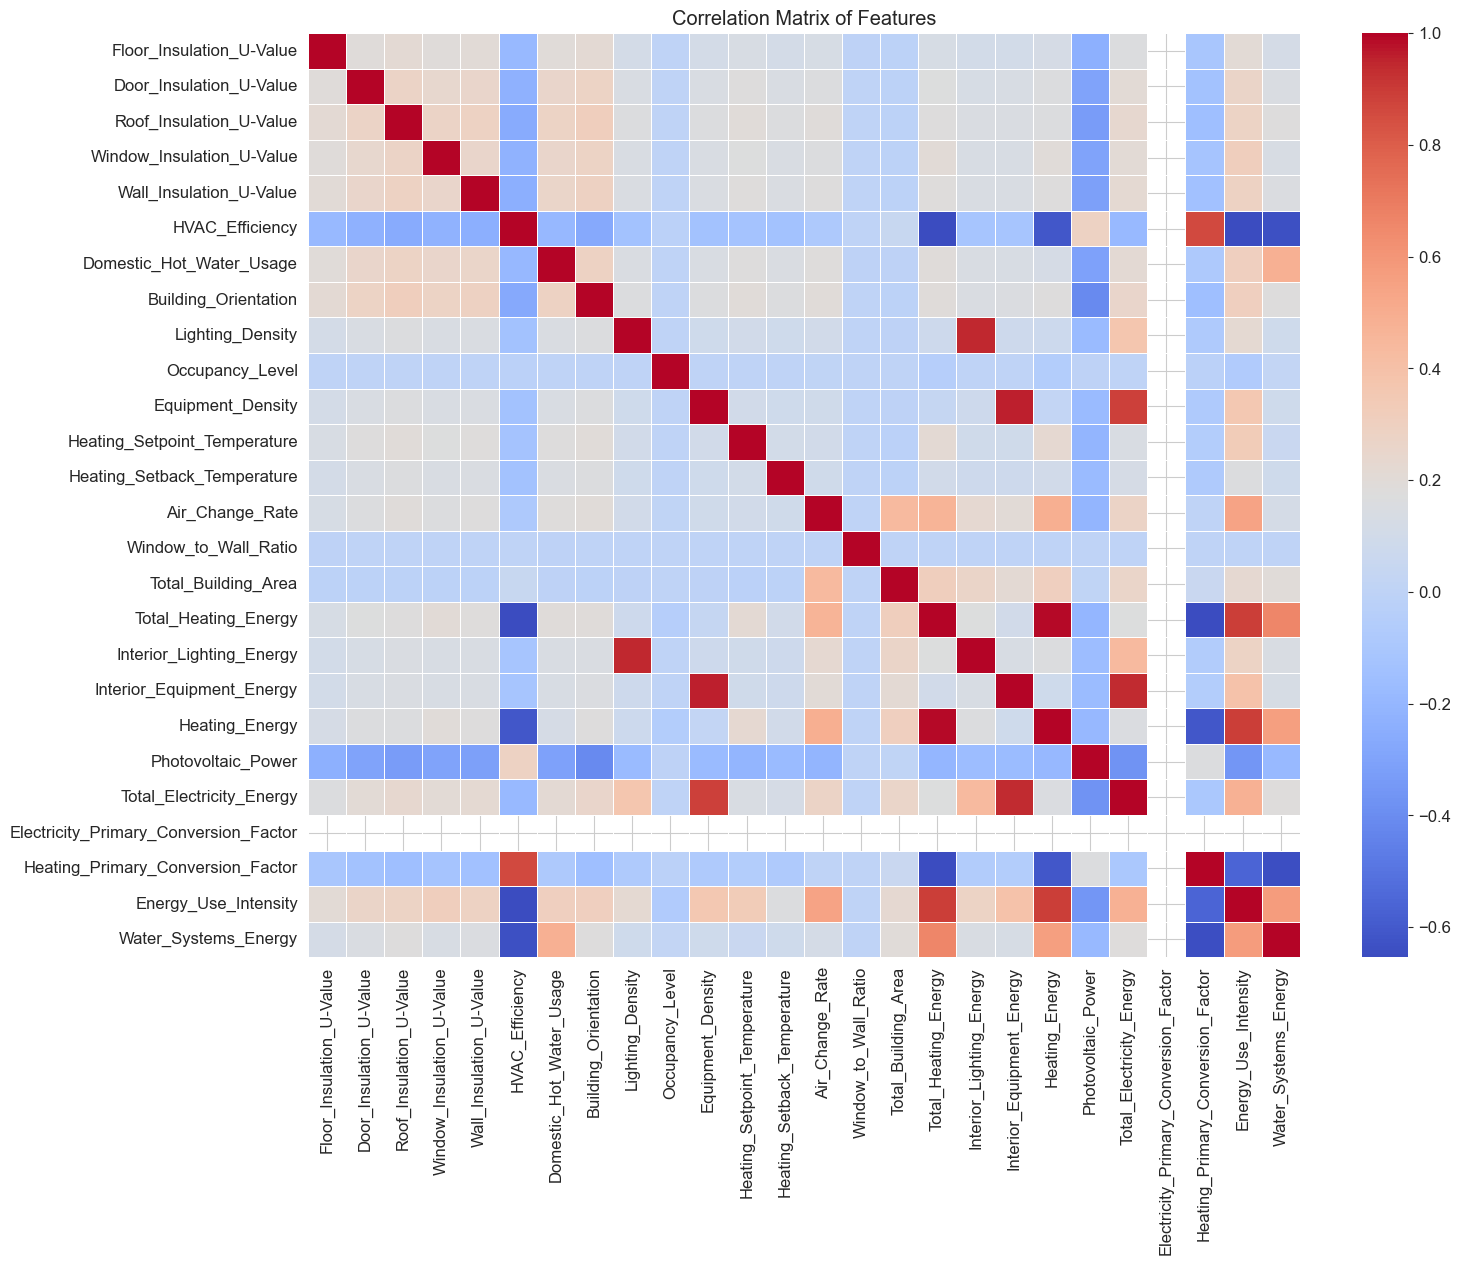

In [72]:
# Correlation only works with numerical data
plt.figure(figsize=(16, 12))
corr_matrix = df[numeric_cols].corr()

# Heatmap
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix of Features")
plt.show()

In [73]:
# Identify categorical columns (object/string types)
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

# Identify numerical columns (int + float types)
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()

print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numeric_cols)


Categorical Columns: ['Simple_Building_Energy_Rating', 'Weather_File', 'Building_Type', 'Renewable_Energy_Usage', 'Building_Energy_Rating']
Numerical Columns: ['Floor_Insulation_U-Value', 'Door_Insulation_U-Value', 'Roof_Insulation_U-Value', 'Window_Insulation_U-Value', 'Wall_Insulation_U-Value', 'HVAC_Efficiency', 'Domestic_Hot_Water_Usage', 'Building_Orientation', 'Lighting_Density', 'Occupancy_Level', 'Equipment_Density', 'Heating_Setpoint_Temperature', 'Heating_Setback_Temperature', 'Air_Change_Rate', 'Window_to_Wall_Ratio', 'Total_Building_Area', 'Total_Heating_Energy', 'Interior_Lighting_Energy', 'Interior_Equipment_Energy', 'Heating_Energy', 'Photovoltaic_Power', 'Total_Electricity_Energy', 'Electricity_Primary_Conversion_Factor', 'Heating_Primary_Conversion_Factor', 'Energy_Use_Intensity', 'Water_Systems_Energy']


In [74]:
# For categorical columns
for col in ['Simple_Building_Energy_Rating', 'Weather_File', 'Building_Type', 'Renewable_Energy_Usage', 'Building_Energy_Rating']:
    print(df[col].value_counts())
    print("\n")

Simple_Building_Energy_Rating
C    274260
B    271292
A    218883
D    132265
E     70653
G     47933
F     33276
Name: count, dtype: int64


Weather_File
Historical    527599
2030          520963
Name: count, dtype: int64


Building_Type
Bungalow         280281
Semi Detached    259925
Detached         254310
Terraced         254046
Name: count, dtype: int64


Renewable_Energy_Usage
Yes    632238
No     416324
Name: count, dtype: int64


Building_Energy_Rating
C1    106854
B3     99828
A3     99818
C2     94614
B1     88130
B2     83334
A2     76516
D1     73507
C3     72792
D2     58758
G      47933
A1     42549
E1     41146
F      33276
E2     29507
Name: count, dtype: int64




In [75]:
target = "Simple_Building_Energy_Rating"

# Drop Leakage Columns
leakage_cols = [
    'Total_Heating_Energy', 'Interior_Lighting_Energy', 'Interior_Equipment_Energy',
    'Heating_Energy', 'Photovoltaic_Power', 'Total_Electricity_Energy',
    'Energy_Use_Intensity', 'Water_Systems_Energy', 'Building_Energy_Rating',
    'Electricity_Primary_Conversion_Factor', 'Heating_Primary_Conversion_Factor'
]
cols_to_drop = [c for c in leakage_cols if c in df.columns]
df = df.drop(columns=cols_to_drop)

print(f"Data Shape: {df.shape}")

Data Shape: (1048562, 20)


In [76]:
X = df.drop(columns=[target])
y = df[target].copy()

# Physics-Informed Features
X["Global_U_Value"] = (X["Window_Insulation_U-Value"] * X["Window_to_Wall_Ratio"] + 
                       X["Wall_Insulation_U-Value"] * (1 - X["Window_to_Wall_Ratio"]))
X["Thermostat_Delta"] = X["Heating_Setpoint_Temperature"] - X["Heating_Setback_Temperature"]
X["Internal_Load_Score"] = (X["Lighting_Density"] + X["Equipment_Density"] + 
                            (X["Occupancy_Level"] * 100 / (X["Total_Building_Area"] + 1)))
X["HVAC_Load_Factor"] = X["Total_Building_Area"] / (X["HVAC_Efficiency"] + 0.1)
X["Infiltration_Loss_Potential"] = (X["Air_Change_Rate"] * X["Total_Building_Area"] * X["Thermostat_Delta"])
X["Weighted_Roof_U"] = X["Total_Building_Area"] * X["Roof_Insulation_U-Value"]

# Cyclical Encoding
X["Orientation_Sin"] = np.sin(np.deg2rad(X["Building_Orientation"]))
X["Orientation_Cos"] = np.cos(np.deg2rad(X["Building_Orientation"]))
X = X.drop(columns=["Building_Orientation"])

In [77]:
cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()

# Preprocessing Pipeline (MinMax Scaler)
preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), 
                      ("scaler", MinMaxScaler())]), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
])

# Encoding Target
le = LabelEncoder()
y_encoded = le.fit_transform(y)
classes = le.classes_
n_classes = len(classes)

# Split
X_train_raw, X_temp, y_train, y_temp = train_test_split(X, y_encoded, test_size=0.30, random_state=42, stratify=y_encoded)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

# Transform
X_train = preprocessor.fit_transform(X_train_raw)
X_val = preprocessor.transform(X_val_raw)
X_test = preprocessor.transform(X_test_raw)

# One-Hot Targets
y_train_oh = to_categorical(y_train, num_classes=n_classes)
y_val_oh = to_categorical(y_val, num_classes=n_classes)

print(f"Training Data Shape: {X_train.shape}")

Training Data Shape: (733993, 31)


In [78]:
# Get feature names
feature_names = preprocessor.get_feature_names_out()

# Print the list
print(f"Total Number of Features: {len(feature_names)}")
print("-" * 30)
for i, col in enumerate(feature_names):
    print(f"{i}: {col}")

Total Number of Features: 31
------------------------------
0: num__Floor_Insulation_U-Value
1: num__Door_Insulation_U-Value
2: num__Roof_Insulation_U-Value
3: num__Window_Insulation_U-Value
4: num__Wall_Insulation_U-Value
5: num__HVAC_Efficiency
6: num__Domestic_Hot_Water_Usage
7: num__Lighting_Density
8: num__Occupancy_Level
9: num__Equipment_Density
10: num__Heating_Setpoint_Temperature
11: num__Heating_Setback_Temperature
12: num__Air_Change_Rate
13: num__Window_to_Wall_Ratio
14: num__Total_Building_Area
15: num__Global_U_Value
16: num__Thermostat_Delta
17: num__Internal_Load_Score
18: num__HVAC_Load_Factor
19: num__Infiltration_Loss_Potential
20: num__Weighted_Roof_U
21: num__Orientation_Sin
22: num__Orientation_Cos
23: cat__Weather_File_2030
24: cat__Weather_File_Historical
25: cat__Building_Type_Bungalow
26: cat__Building_Type_Detached
27: cat__Building_Type_Semi Detached
28: cat__Building_Type_Terraced
29: cat__Renewable_Energy_Usage_No
30: cat__Renewable_Energy_Usage_Yes


In [79]:
# Focal Loss Function
def categorical_focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * y_true * tf.math.pow((1 - y_pred), gamma)
        loss = weight * cross_entropy
        return tf.reduce_sum(loss, axis=1)
    return focal_loss_fixed

# (Input: 1024 -> Hidden: 128 -> Hidden: 256)
model = Sequential()

# Input Layer
model.add(Dense(1024, input_dim=X_train.shape[1], kernel_regularizer=l2(0.0001)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.1))  

# Hidden Layer 1
model.add(Dense(128, kernel_regularizer=l2(0.0001)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.1))  

# Hidden Layer 2
model.add(Dense(256, kernel_regularizer=l2(0.0001)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.1))  

# Output Layer
model.add(Dense(n_classes, activation='softmax'))

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss=categorical_focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy']
)

model.summary()

C:\Users\Aylin\anaconda3\envs\intelligencebuiltenv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 1024)           │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 204,423 (798.53 KB)

 Trainable params: 201,607 (787.53 KB)

 Non-trainable params: 2,816 (11.00 KB)

In [80]:
checkpoint_path = "best_model.keras"

callbacks = [
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    
    # Saves the model with the best validation accuracy
    ModelCheckpoint(filepath=checkpoint_path, monitor='val_accuracy', mode='max', save_best_only=True, verbose=1)
]

history = model.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=100,      
    batch_size=512, 
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
1434/1434 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7081 - loss: 0.1221
Epoch 1: val_accuracy improved from None to 0.79322, saving model to best_model.keras
1434/1434 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.7475 - loss: 0.0923 - val_accuracy: 0.7932 - val_loss: 0.0618 - learning_rate: 5.0000e-04
Epoch 2/100
1434/1434 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7799 - loss: 0.0610
Epoch 2: val_accuracy improved from 0.79322 to 0.82046, saving model to best_model.keras
1434/1434 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.7864 - loss: 0.0566 - val_accuracy: 0.8205 - val_loss: 0.0448 - learning_rate: 5.0000e-04
Epoch 3/100
1431/1434 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7983 - loss: 0.0487
Epoch 3: val_accuracy improved from 0.82046 to 0.82417, saving model to best_model.keras
1434/1434 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.7998 - loss: 0.0476 - val_accuracy: 0.8242 - val_loss: 0.0405 - learning_rate: 5.0000e-04
Epoch 4/100
1433/14

In [81]:
# Custom objects needed because of custom loss function
model = load_model(checkpoint_path, custom_objects={'focal_loss_fixed': categorical_focal_loss(gamma=2.0, alpha=0.25)})

# Evaluate on Test Set
test_loss, test_acc = model.evaluate(X_test, to_categorical(y_test, num_classes=n_classes))
print(f"🏆 Final Test Accuracy: {test_acc*100:.2f}%")

4916/4916 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.9002 - loss: 0.0198
🏆 Final Test Accuracy: 90.02%


4916/4916 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step


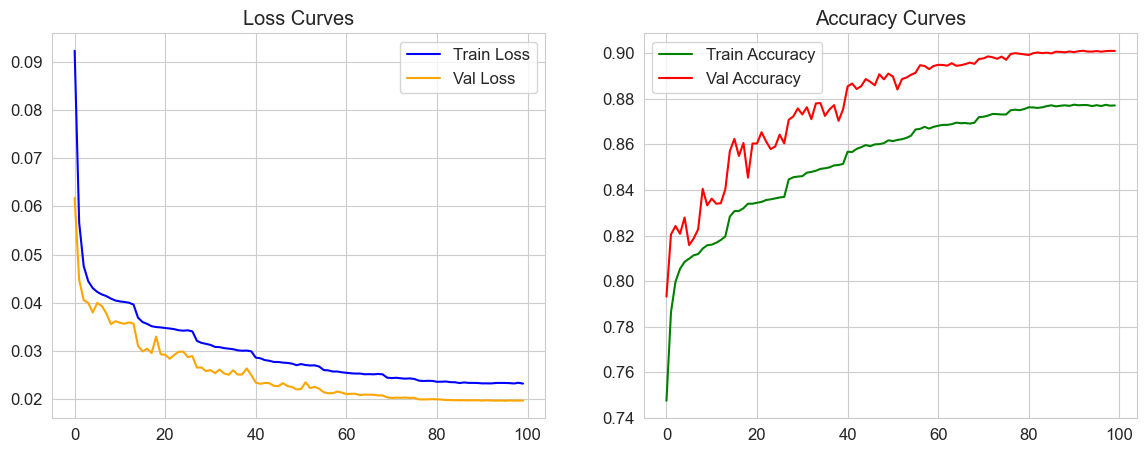

In [82]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# 1. Loss & Accuracy Curves
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title('Loss Curves')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='green')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='red')
plt.title('Accuracy Curves')
plt.legend()
plt.show()

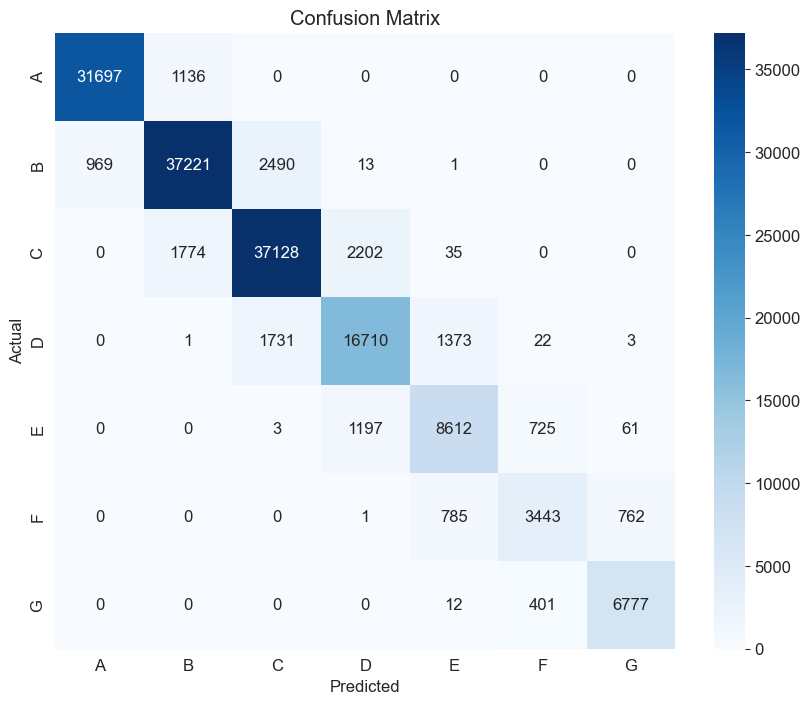

In [83]:
# 2. Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [84]:
# 3. Metrics
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred, target_names=classes, digits=4))
print(f"Cohen's Kappa Score: {cohen_kappa_score(y_test, y_pred):.4f}")


--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           A     0.9703    0.9654    0.9679     32833
           B     0.9275    0.9147    0.9210     40694
           C     0.8979    0.9025    0.9002     41139
           D     0.8304    0.8422    0.8363     19840
           E     0.7961    0.8126    0.8043     10598
           F     0.7499    0.6898    0.7186      4991
           G     0.8914    0.9426    0.9162      7190

    accuracy                         0.9002    157285
   macro avg     0.8662    0.8671    0.8664    157285
weighted avg     0.9003    0.9002    0.9001    157285

Cohen's Kappa Score: 0.8749


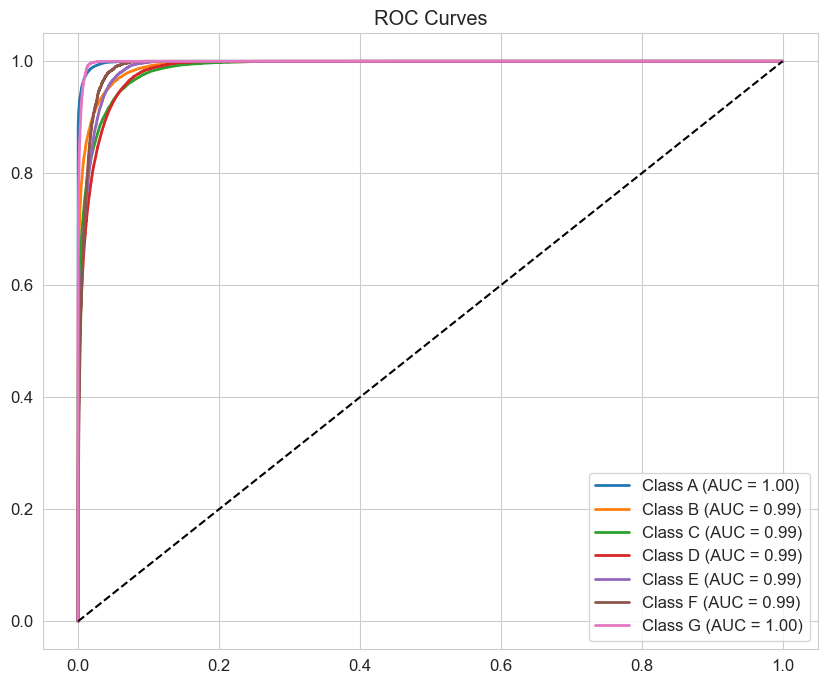

In [85]:
# 4. ROC Curves
y_test_bin = label_binarize(y_test, classes=range(n_classes))
fpr = dict(); tpr = dict(); roc_auc = dict()
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=2, label=f'Class {classes[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curves')
plt.legend(loc="lower right")
plt.show()

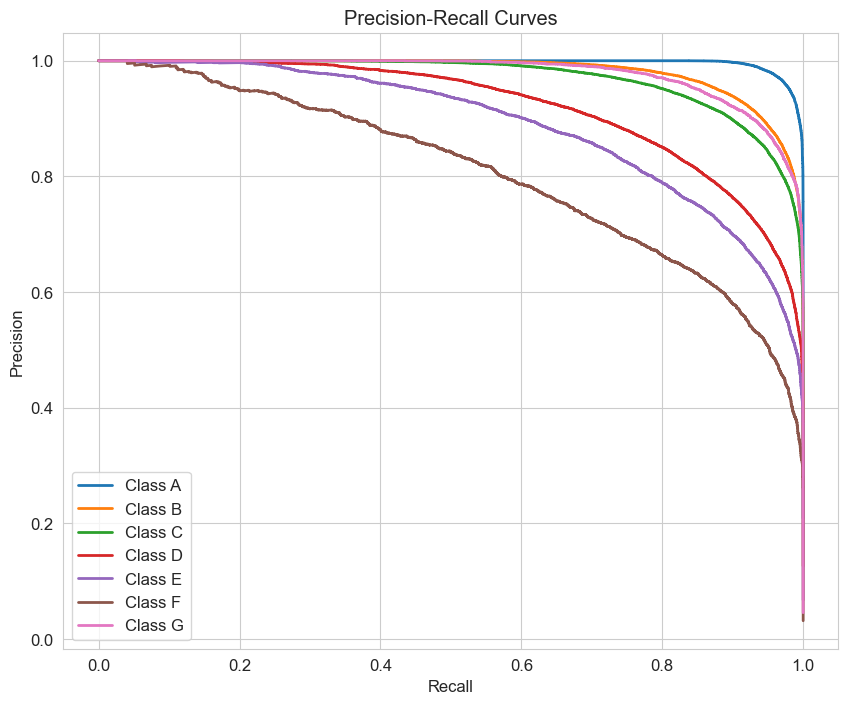

In [86]:
# 5. Precision-Recall
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_probs[:, i])
    plt.plot(recall, precision, lw=2, label=f'Class {classes[i]}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend(loc="best")
plt.show()